## Title
Land Use Classification from Satellite Imagery using Random Forest

## Introduction
This project uses machine learning to classify satellite images into different land cover categories such as 'Forests', 'Industrial', 'Residential', and 'River' using the EuroSAT dataset.

## Dataset Description

This project uses the EuroSAT RGB dataset, a satellite imagery dataset commonly used for land use and land cover classification tasks in remote sensing and geospatial analysis.

The dataset contains RGB satellite images grouped into 10 land cover categories:

- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake

Each image represents a specific type of land use or environmental feature captured from satellite imagery.

The dataset is organized into separate folders for each class, making it suitable for supervised machine learning classification tasks.

For this project, the images were resized to 64 × 64 pixels and converted into numerical arrays for model training.

In [ ]:
import os
print(os.listdir('/kaggle/input'))
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
print(os.listdir('/kaggle/input/datasets'))

In [ ]:
print(os.listdir('/kaggle/input/datasets/waseemalastal'))

In [ ]:
print(os.listdir('/kaggle/input/datasets/waseemalastal/eurosat-rgb-dataset'))

In [ ]:
data_dir = '/kaggle/input/datasets/waseemalastal/eurosat-rgb-dataset/EuroSAT_RGB'
print(os.listdir(data_dir))

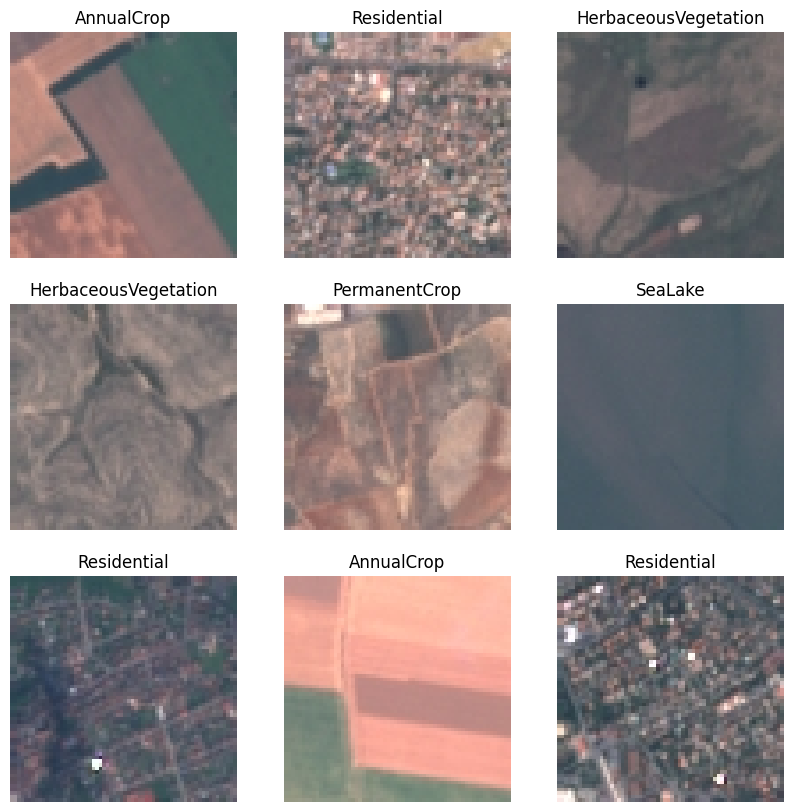

In [5]:
# Display a sample of satelite images
import random
from PIL import Image
import matplotlib.pyplot as plt
import os
# set dataset path
data_dir = '/kaggle/input/datasets/waseemalastal/eurosat-rgb-dataset/EuroSAT_RGB'
categories = os.listdir(data_dir)
# create a canvas for plotting images
plt.figure(figsize=(10,10))
#loop to display 9 random images
for i in range(9):
    category = random.choice(categories)
    # get path to that category
    img_path = os.path.join(data_dir,category)
    # pick a random image file from that folder
    img_file = random.choice(os.listdir(img_path))
    # open the image
    img = Image.open(os.path.join(img_path,img_file))
    # plot the image
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.show()


In [6]:
# prepare data(convert images into arrays and create features and labels)
# create empty lists
X = [] # will store images(features)
y = [] # will store labels as numbers
for category in categories:
    path = os.path.join(data_dir,category)
    label = categories.index(category)

    for img_file in os.listdir(path)[:200]: # limit for speed
        img = Image.open(os.path.join(path,img_file)).resize((64,64))
    
        # convert image into array
        X.append(np.array(img))
        # store labels
        y.append(label)
        # convert lists to arrays
X = np.array(X)
y = np.array(y)

print(X.shape,y.shape)


(2000, 64, 64, 3) (2000,)


In [8]:
# split the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)


In [9]:
# buid a simple model
from sklearn.ensemble import RandomForestClassifier
# flatten the images so the model can understand
X_train_flat = X_train.reshape(len(X_train),-1)
X_test_flat = X_test.reshape(len(X_test),-1)
# create a model instance and fit model
model = RandomForestClassifier(n_estimators = 50)
model.fit(X_train_flat,y_train)
# calculate the accuracy of the model
accuracy = model.score(X_test_flat,y_test)
print("accuracy:", accuracy)


accuracy: 0.5425


In [10]:
# evaluate model
from sklearn.metrics import classification_report
y_pred = model.predict(X_test_flat)
print(classification_report(y_test,y_pred, target_names = categories))

                      precision    recall  f1-score   support

             SeaLake       0.76      0.89      0.82        36
             Highway       0.33      0.15      0.21        47
               River       0.66      0.54      0.60        46
             Pasture       0.46      0.86      0.60        36
          Industrial       0.60      0.79      0.68        34
         Residential       0.33      0.32      0.33        34
       PermanentCrop       0.24      0.27      0.25        33
          AnnualCrop       0.58      0.48      0.53        44
              Forest       0.76      0.85      0.80        48
HerbaceousVegetation       0.50      0.31      0.38        42

            accuracy                           0.54       400
           macro avg       0.52      0.55      0.52       400
        weighted avg       0.53      0.54      0.52       400



The model performed best on visually distinct classes such as SeaLake and Forest, while agricultural and vegetation-related classes were harder to distinguish.

### Why Random Forest Was Chosen

I chose Random Forest as the baseline model because it works well with structured numerical data, requires minimal preprocessing, and trains faster than most deep learning models. It also provides a strong starting point for evaluating image classification performance before progressing to more advanced approaches such as Convolutional Neural Networks (CNNs).